# Chapter 5 — Honesty and dynamics

Two earlier chapters left a promissory note here. Chapter 1 (§1.2) flagged *"a run that shrank its self-gap while its edge stood still"*; Chapter 3 (§3.3) deferred the question of **training length** to this chapter. Both come due now — and both turn out to be the same kind of story.

This chapter is not about a new result. It is about **measurement**: the two ways our own metrics tried to flatter us, and the discipline that caught them before they reached the headline. The function-approximation floor of Chapter 4 is still the floor; what follows is how we kept ourselves from claiming more than the floor allows.

## 5.1 — A metric that graded its own homework

The diff doesn't just count matches against basic strategy. It splits every *disagreement* into two kinds, using the agent's **own** Q-values:

- **genuine disagreement** — the agent's network clearly prefers its action over basic's (a wide self-estimated EV gap);
- **near-tie** (`near_equal_ev`) — by the agent's own estimate the two actions are within an EV tolerance, too close to call.

That split is useful, but it has a trap built in. As Q-values converge with longer training, the agent's self-estimated gaps **shrink** — and cells that were genuine disagreements slide under the tolerance and get re-labelled near-ties. The diff looks cleaner. Nothing was fixed.

Here is the matched pair Chapter 1 promised: the *same* agent and seed, trained 1.5M vs 5M episodes — only the length differs.

training,agree_cells,genuine,near_tie,self_gap,agreement,edge_pct
1.5M ep,209,28,3,0.29,87.1%,1.21
5M ep,210,23,7,0.28,87.5%,1.25


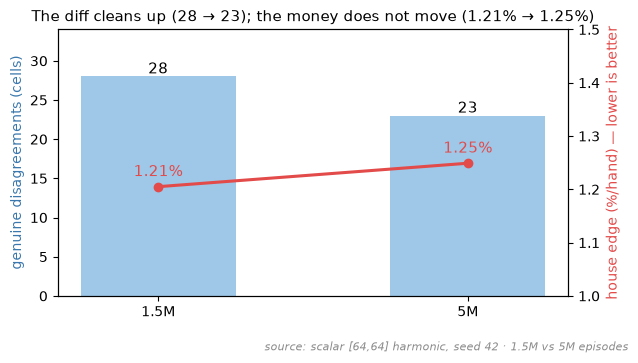

In [1]:
import sys; sys.path.insert(0, '.')
import json as _j
from pathlib import Path as _P
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from runs import load_runs, learning_curve, show, provenance, fignote, describe

df = load_runs(); dqn = df[df.method == 'dqn']

# matched pair: identical config & seed, training length is the ONLY difference
def _pick(ep):
    s = dqn[(dqn.encoding == 'scalar') & (dqn.hidden == '[64, 64]') & (dqn.lr_schedule == 'harmonic')
            & dqn.double_dqn & (dqn.reward_baseline == 'stand') & (dqn.double_after > 0)
            & (dqn.episodes == ep) & (dqn.seed == 42)]
    return s.iloc[0]
short, long_ = _pick(1_500_000), _pick(5_000_000)

def _selfgap(row):
    cells = _j.load(open(_P(row.path) / 'record.json', encoding='utf-8'))['diff']['cells']
    cnt = Counter(c['category'] for c in cells)
    gen = [c for c in cells if c['category'] == 'genuine_disagreement']
    sg = float(np.mean([abs(c['agent_q'] - c['basic_q']) for c in gen]))  # mean self-estimated EV gap
    return dict(training='%gM ep' % (row.episodes / 1e6), agree_cells=cnt['agree'],
                genuine=cnt['genuine_disagreement'], near_tie=cnt['near_equal_ev'],
                self_gap=sg, agreement=row.agreement, edge_pct=row.edge_pct)

tab = pd.DataFrame([_selfgap(short), _selfgap(long_)])
show(tab, pct=['agreement'], num=['self_gap', 'edge_pct'],
     caption='Train the same agent 3.3x longer: the disagreement count falls, the edge does not',
     source='source: matched pair, identical config & seed, length is the only difference — '
            'DQN · scalar · [64, 64] · harmonic · Double-DQN · stand-baseline · double@500k · seed 42')

# the divergence, drawn: genuine-disagreement count drops while edge holds
fig, ax1 = plt.subplots(figsize=(6.4, 3.4))
x = [0, 1]; lbl = ['1.5M', '5M']
ax1.bar(x, tab.genuine, width=0.5, color='#9ec7e8', label='genuine disagreements')
for xi, v in zip(x, tab.genuine): ax1.text(xi, v + 0.4, str(int(v)), ha='center', fontsize=11)
ax1.set_ylabel('genuine disagreements (cells)', color='#3a78ad')
ax1.set_xticks(x); ax1.set_xticklabels(lbl); ax1.set_ylim(0, 34)
ax2 = ax1.twinx()
ax2.plot(x, tab.edge_pct, '-o', color='#e24b4a', lw=2.2, label='house edge')
for xi, v in zip(x, tab.edge_pct): ax2.text(xi, v + 0.02, '%.2f%%' % v, ha='center', color='#e24b4a', fontsize=11)
ax2.set_ylabel('house edge (%/hand) — lower is better', color='#e24b4a'); ax2.set_ylim(1.0, 1.5)
ax1.set_title('The diff cleans up (28 → 23); the money does not move (1.21% → 1.25%)', fontsize=11)
fignote('source: scalar [64,64] harmonic, seed 42 · 1.5M vs 5M episodes')
plt.tight_layout(); plt.show()

**Reading it.** Five genuine disagreements (28 → 23) vanished from the "genuine" column — and four of them reappeared as near-ties (3 → 7). The agent's mean self-gap on the cells it still disagrees on shrank (0.29 → 0.28). Every aggregate that the agent computes *about itself* says the diff got cleaner.

But the agent plays those cells exactly as before. The proof is in the two metrics that face the ruler, not the agent: the house **edge** did not improve (1.21% → 1.25%, if anything a hair worse) and **agreement** is flat (0.871 → 0.875). Longer training made the agent *more confident that its mistakes weren't mistakes* — it did not make them stop being mistakes.

The lesson is a rule for the rest of the report: **the self-gap and the genuine/near split measure the agent's certainty, not its correctness.** Trust the edge (money lost against basic on the same hands) and agreement (action-match against the proven-optimal ruler). Distrust any number computed from the agent's own Q-values — it grades its own homework.

## 5.2 — The peak that wasn't a home

Now the training-length question Chapter 3.3 deferred. Watch evaluation agreement over a long run and you don't see a tidy climb to a final value. You see it **spike** to a high-water mark early or mid-run, then settle onto a lower plateau and stay there. The peak is a transient — a lucky alignment of borderline cells — not a level the model holds.

In [2]:
five = dqn[(dqn.episodes == 5_000_000) & (~dqn.with_splits)].copy()

def _dyn(row):
    lc = learning_curve(row.path)
    pts = [(cp['episode'], cp['agreement']) for cp in lc if 'agreement' in cp]
    eps = np.array([p[0] for p in pts]); ag = np.array([p[1] for p in pts]); mx = eps.max()
    bh = ag[eps > mx / 2]
    enc = '%s %s' % (row.encoding, row.hidden)
    return dict(config=enc, episodes='%gM' % (row.episodes / 1e6),
                peak=float(ag.max()), peak_at='%.1fM' % (eps[ag.argmax()] / 1e6),
                back_half=float(bh.mean()), peak_minus_plateau=float(ag.max() - bh.mean()))

rows = [_dyn(r) for _, r in five.iterrows()]
# the longest run we have: 10M episodes (the split-aware agent of Ch6) — a different game, shown softly
ten = dqn[(dqn.episodes == 10_000_000)]
if len(ten):
    d = _dyn(ten.iloc[0]); d['config'] += ' (+splits, 10M)'; rows.append(d)

tab2 = pd.DataFrame(rows).sort_values('back_half', ascending=False)
show(tab2, pct=['peak', 'back_half', 'peak_minus_plateau'],
     caption='Single-checkpoint peak vs the steady back-half level it never sustains',
     source='source: each row a single 5M run (one seed) · peak = best checkpoint, back_half = mean over the '
            'final half of training · last row is the 10M split-aware run (Problem of Ch6), shown for length only')

config,episodes,peak,peak_at,back_half,peak_minus_plateau
"onehot [64, 64]",5M,93.3%,4.6M,91.1%,2.3%
"scalar [64, 64]",5M,93.3%,1.7M,88.5%,4.9%
"onehot [16, 16]",5M,92.1%,0.7M,87.3%,4.7%
"onehot [16, 16] (+splits, 10M)",10M,87.4%,4.9M,84.7%,2.6%
"onehot [256, 256]",5M,89.2%,3.0M,84.1%,5.1%


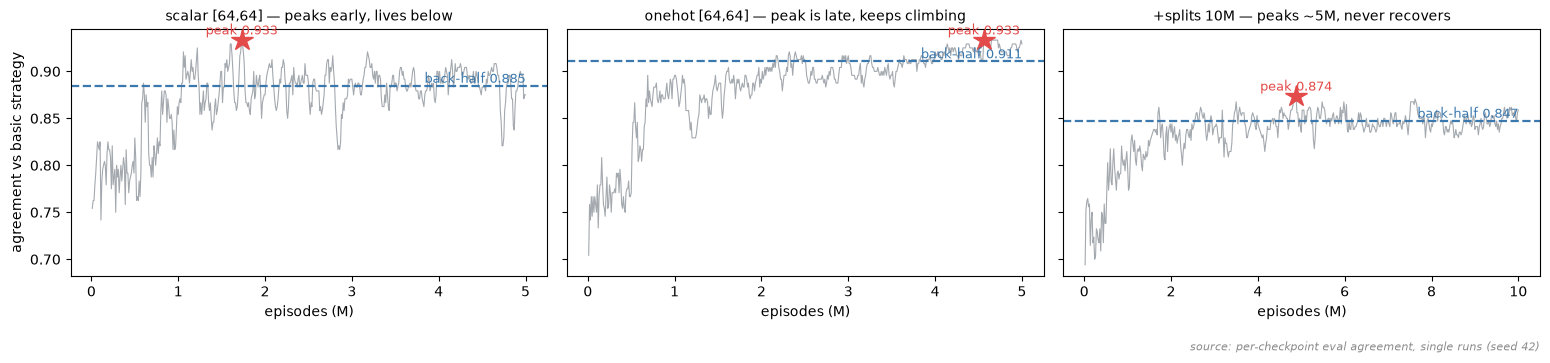

In [3]:
# the shape, drawn: an early-peaking run and the 10M run — peak (star) sits above the back-half band
def _trace(row):
    lc = learning_curve(row.path)
    pts = [(cp['episode'], cp['agreement']) for cp in lc if 'agreement' in cp]
    return np.array([p[0] for p in pts]) / 1e6, np.array([p[1] for p in pts])

scalar5 = five[(five.encoding == 'scalar')].iloc[0]
best5   = five[(five.encoding == 'onehot') & (five.hidden == '[64, 64]')].iloc[0]
panels = [('scalar [64,64] — peaks early, lives below', scalar5),
          ('onehot [64,64] — peak is late, keeps climbing', best5)]
if len(ten): panels.append(('+splits 10M — peaks ~5M, never recovers', ten.iloc[0]))

fig, axes = plt.subplots(1, len(panels), figsize=(5.2 * len(panels), 3.4), sharey=True)
for ax, (title, row) in zip(np.atleast_1d(axes), panels):
    e, a = _trace(row); mx = e.max(); bh = a[e > mx / 2].mean(); pk = a.argmax()
    ax.plot(e, a, color='#9aa0a6', lw=0.8, alpha=0.9)
    ax.axhline(bh, color='#3a78ad', lw=1.6, ls='--')
    ax.text(e.max(), bh, ' back-half %.3f' % bh, color='#3a78ad', va='bottom', ha='right', fontsize=9)
    ax.plot(e[pk], a[pk], '*', color='#e24b4a', ms=16)
    ax.text(e[pk], a[pk] + 0.006, 'peak %.3f' % a[pk], color='#e24b4a', ha='center', fontsize=9)
    ax.set_title(title, fontsize=10); ax.set_xlabel('episodes (M)')
np.atleast_1d(axes)[0].set_ylabel('agreement vs basic strategy')
fignote('source: per-checkpoint eval agreement, single runs (seed 42)')
plt.tight_layout(); plt.show()

**Reading it.** Across the 5M runs the single best checkpoint sits **~5 points above** the steady back-half level. Scalar peaks 0.933 at 1.7M but *lives* at 0.885; the small [16,16] net peaks 0.921 at 0.65M but lives at 0.873. Had we early-stopped on the eval metric or reported "best checkpoint," we'd have claimed about five points we could not reproduce. That is why every number in this report is a **back-half mean, never a peak**.

And longer is not reliably better. Only the best-matched config — onehot [64,64] — has its peak *late* and keeps climbing through the run; the others top out early and the extra millions of episodes buy a plateau, not a climb. The longest run we have, 10M episodes, makes the point at length: agreement peaked 0.874 near 5M and the following 5M never recovered it, settling at 0.847. We don't lean on that hard — it is a single run on the split-aware game of Chapter 6 — but the shape is the same one the 5M runs show, just stretched out: **past the knee, more training holds steady at best, and can settle a touch below its own high-water mark.** "More training is worse" is too strong; "more training stops helping, and the peak you saw was a transient" is exactly right.

## 5.3 — The discipline

Putting Chapters 2–5 together, the rules that kept the conclusions honest were all about *what to measure and what to compare*:

**Pair every comparison.** Agent and basic strategy play the *same* seeded hands in the same fresh-shoe harness, so the edge difference is a real difference, not two different draws (Chapter 1).

**Match before you attribute.** Only compare runs that differ in the one thing under test. Chapter 3.3's [64,64] group looked like a capacity effect until we found it was contaminated by lr and Double-DQN variants; Chapter 3.4 only trusted exploring-starts after matching training length.

**Report the back-half mean, not a peak or a single checkpoint.** The eval metric peaks transiently ~5 points above where the model actually lives (5.1, 5.2). A peak is not reproducible; the back-half mean is.

**Trust the metrics that face the ruler.** Agreement (action-match) and edge (money against basic) are graded by the proven-optimal table. Distrust numbers the agent computes about *itself* — the self-gap and the genuine/near-tie split shrink with confidence, not with correctness (5.1) — and distrust aggregates that can hide a confound, like the dealer-upcard variance of Chapter 3.5.

None of this changed the headline. The function-approximation floor of Chapter 4 — the one sharp wall the smooth net can't build at the double's edge — is still the floor. The discipline is simply what lets us state that floor without flinching, and what stopped us from claiming an "overtraining cliff," a "self-gap improvement," or a "best-checkpoint" score that the data would not back.